In [10]:
import os
import re
import sys
import json
import itertools
from pathlib import Path
import pandas as pd
from collections import defaultdict
import gurobipy as gp

from module import (
    route_prefix,
    travel_time_only,
    build_sched,
    od_distance_on_planned,
    planned_eids_of,
    get_arrival,
    build_arc_list_window,
    build_model_window,
    node_cap,
    merge_orders,
    build_canonical_station_order,
    sched_arr,
    sched_dep,
    plot_train_paths,
    h_get,
    plot_all_lines_global,
    plot_selected_lines,
    build_line_yorder,
    plot_lines_dynamic_y,
)

## Load data

In [11]:
# Horizon and capacities
T          = 72
max_wait   = 4
CAPACITY_EDGE = 20
CAPACITY_NODE = 20

# Incident window and modelling constants
failed_edges = {"e43", "e43r"}
FAIL_T   = 48
T_clear  = 96
DWELL_MIN = 1
BIG_M     = 10**6


REGION = "kor"   # or "kor"
MODULE_DIR = Path.cwd().resolve()
sys.path.insert(0, str(MODULE_DIR))

from inputs import input_files_kor, input_files_uk

fp = input_files_kor if REGION == "kor" else input_files_uk

edges_raw = json.loads(fp["edges"].read_text(encoding="utf-8"))
routes_nodes = json.loads(fp["route"].read_text(encoding="utf-8"))
dep_time_raw = json.loads(fp["dept"].read_text(encoding="utf-8"))
dem_raw = json.loads(fp["demand"].read_text(encoding="utf-8"))

dep_time = {tr: int(t) for tr, t in dep_time_raw.items()}
edges = {
    eid: (edata["from"], edata["to"], int(edata["tau"]))  # (o, d, q) = (from, to, tau)
    for eid, edata in edges_raw.items()
}
demand = {tr: [(o, d, float(q)) for o, d, q in lst] for tr, lst in dem_raw.items()}
trains = list(routes_nodes)
SINK   = "SINK"
nodes  = {n for _, (s, d, _) in edges.items() for n in (s, d)}
nodes.add(SINK)


## Settings

In [12]:
import module as md

md.T            = T
md.FAIL_T       = FAIL_T
md.T_clear      = T_clear
md.DWELL_MIN    = DWELL_MIN
md.BIG_M        = BIG_M
md.CAPACITY_NODE = CAPACITY_NODE
md.SINK         = SINK
md.trains       = trains
md.routes_nodes = routes_nodes
md.dep_time     = dep_time
md.demand       = demand
md.nodes        = nodes
md.failed_edges = failed_edges
md.edges        = edges

In [13]:
sched = build_sched(routes_nodes, edges, dep_time, DWELL_MIN)
node_pos = {tr: {n: i for i, n in enumerate(path)} for tr, path in routes_nodes.items()}
edge_tau = {(s, d): tau for _, (s, d, tau) in edges.items()}

md.routes_nodes = routes_nodes
md.node_pos     = node_pos
md.edge_tau     = edge_tau

d_rd, qd_rd = {}, {}
for tr in trains:
    for (o, d, q) in demand[tr]:
        dd = od_distance_on_planned(tr, o, d)
        d_rd[(tr, o, d)]  = dd
        qd_rd[(tr, o, d)] = q * dd

md.sched = sched
md.qd_rd = qd_rd


In [14]:
# Group trains by route base
by_route = defaultdict(list)
for tr in trains:
    by_route[route_prefix(tr)].append(tr)


# Representative runtime per route base
route_runtime = {}
for rname, tr_list in by_route.items():
    reps = [tr for tr in tr_list if re.fullmatch(re.escape(rname) + r'\d+_1', tr)]
    if not reps:
        reps = [tr for tr in tr_list if tr.endswith('_1')]
    if not reps:
        reps = [sorted(tr_list)[0]]
    rep = reps[0]
    route_runtime[rname] = travel_time_only(routes_nodes[rep], edges)


# Time limit per train
PADDING_BASE = 6
T_limit = {}
for tr in trains:
    L = len(routes_nodes[tr]) - 1
    dwell_need = max(0, L-1) * DWELL_MIN
    base_run = route_runtime[route_prefix(tr)]
    T_limit[tr] = min(T, dep_time[tr] + base_run + dwell_need + PADDING_BASE)


# Map (u,v) to eid
uv2eid, dup_keys = {}, set()

for eid, (s, d, _) in edges.items():
    key = (s, d)
    if key in uv2eid and uv2eid[key] != eid:
        dup_keys.add(key)
    else:
        uv2eid[key] = eid
if dup_keys:
    print(f"[warn] duplicated (u,v) keys exist: {sorted(list(dup_keys))[:5]} ...")

md.uv2eid = uv2eid


# Planned eids
planned_eids = {tr: planned_eids_of(tr) for tr in trains}
blocked      = {tr: int(any(e in failed_edges for e in planned_eids[tr])) for tr in trains}
T_aff        = [tr for tr in trains if blocked[tr] == 1]
T_ok         = [tr for tr in trains if blocked[tr] == 0]


# Allowable termination nodes after incident position
allow_stop, reach = {}, {}
for tr in trains:
    path  = routes_nodes[tr]
    eids  = planned_eids[tr]
    L     = len(path) - 1
    last  = path[-1]
    t_arrival_last = get_arrival(tr, last, default=10**9)
    reach[tr] = int(t_arrival_last <= T_limit[tr])

    first_fail = next((idx for idx, e in enumerate(eids) if e in failed_edges), None)
    for i in range(1, L + 1):
        n = path[i]
        if i == L:
            allow = 1
        elif reach[tr] == 0:
            allow = 1
        else:
            allow = 1 if (first_fail is not None and i >= (first_fail + 1)) else 0
        allow_stop[(tr, n)] = int(allow)

In [15]:
CROSS = {}
for tr in trains:
    path = routes_nodes[tr]
    t = dep_time[tr]
    for u, v in zip(path[:-1], path[1:]):
        eid = uv2eid[(u, v)]
        tau = edges[eid][2]
        t0, t1 = t, t + tau
        if t0 < FAIL_T <= t1:
            CROSS[tr] = (u, v, eid, t0, t1)
            break
        t = t1
        if v != path[-1]:
            t += DWELL_MIN

## Rail scheduling
Dynamic optimization model

In [16]:
t_win_start = 0
t_win_end   = T

print(f"\n==== Window [{t_win_start}, {t_win_end}) ====")

window_ctx = build_arc_list_window(
    t_start=t_win_start, t_end=t_win_end,
    failed_edges=failed_edges, T_clear=T_clear,
    max_wait=max_wait, nodes=nodes, edges=edges,
    CROSS=CROSS
)

base, xvar, t_arr_var, delta_var, hvar, zvar, svar = build_model_window(
    window_ctx, t_win_start, t_win_end,
    planned_eids, routes_nodes,
    T_aff, T_ok, allow_stop, T_limit)

# edge capacity per time
constr_names = {}
for (eid, tt), idxs in window_ctx["cap_map"].items():
    real_idxs = [k for k in idxs if k >= 0]
    enabled_keys = [(k, ti) for k in real_idxs for ti in range(len(trains)) if (k, ti) in xvar]
    if not enabled_keys:
        continue
    expr = gp.quicksum(xvar[k, ti] for (k, ti) in enabled_keys)
    ghost = sum(1 for i in idxs if i < 0)
    rhs = max(0, CAPACITY_EDGE - ghost)
    base.addConstr(expr <= rhs, name=f"edgecap_{eid}_{tt}")
    constr_names[(eid, tt)] = f"edgecap_{eid}_{tt}"

# node capacity via wait arcs occupancy
node_slot_map = defaultdict(list)
for k, (fr, to, eid, _, t0, t1) in enumerate(window_ctx["arc_list"]):
    if not str(eid).startswith("w_"):
        continue
    n_fr, _ = fr.split("^")
    for tt in range(max(t0, t_win_start), min(t1, t_win_end)):
        node_slot_map[(n_fr, tt)].append(k)

for (n, tt), idxs in node_slot_map.items():
    enabled = [(k, ti) for k in idxs for ti in range(len(trains)) if (k, ti) in xvar]
    if not enabled:
        continue
    occ = gp.quicksum(xvar[k, ti] for (k, ti) in enabled)
    base.addConstr(occ <= node_cap(n), name=f"nodecap_{n}_{tt}")

base.optimize()

if base.Status == gp.GRB.OPTIMAL:
    print(f"[OBJ] optimal objective = {base.ObjVal}")
elif base.Status in (gp.GRB.TIME_LIMIT, gp.GRB.INTERRUPTED):
    print(f"[OBJ] incumbent (best found) = {base.ObjVal}")
    print(f"[BND] best bound = {base.ObjBound}")
    print(f"[GAP] MIP gap = {base.MIPGap:.4%}")
elif base.Status == gp.GRB.INFEASIBLE:
    print("Model infeasible.")
else:
    print(f"Status: {base.Status}")

if base.Status == gp.GRB.INFEASIBLE:
    base.computeIIS()
    for c in base.getConstrs():
        if c.IISConstr:
            print(f"[IIS] {c.ConstrName}")
    for v in base.getVars():
        if getattr(v, "IISLB", 0) or getattr(v, "IISUB", 0):
            print(f"[IIS-Var] {v.VarName}  LB:{v.IISLB}  UB:{v.IISUB}")
    base.write(f"iis_win{t_win_start}_{t_win_end}.ilp")
    raise RuntimeError("infeasible (IIS written)")
elif base.Status != gp.GRB.OPTIMAL:
    raise RuntimeError(f"non-optimal status: {base.Status}")

# Extract solution
x_val   = {key: round(var.X) for key, var in xvar.items()}
h_final = {tr: 1.0 for tr in trains}

sol_legs = {tr: [] for tr in trains}
seen_arc_keys = set()

for tr in trains:
    ti = trains.index(tr)
    if tr in T_aff:
        try:
            h_final[tr] = float(hvar[tr].X)
        except KeyError:
            pass
    for k, (fr, to, eid, tau, t0, t1) in enumerate(window_ctx["arc_list"]):
        if x_val.get((k, ti), 0) <= 0.5:
            continue
        if str(eid).startswith(("w_", "dummy")):
            continue
        u, _t0 = fr.split("^"); v, _t1 = to.split("^")
        _t0 = int(_t0); _t1 = int(_t1)
        if _t1 < 0 or _t0 > T:
            continue
        key = (tr, _t0, u, v, _t1, eid)
        if key not in seen_arc_keys:
            seen_arc_keys.add(key)
            sol_legs[tr].append((_t0, u, v, _t1, eid))

print("Complete: sol_legs length =", {tr: len(sol_legs[tr]) for tr in trains})
print("\n==== Optimization done ====")


==== Window [0, 72) ====
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 5 3600XT 6-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1702049 rows, 3320356 columns and 18398430 nonzeros
Model fingerprint: 0xc4fd9b8d
Model has 1518 quadratic objective terms
Model has 6312 SOS constraints
Variable types: 52479 continuous, 3267877 integer (3267877 binary)
Coefficient statistics:
  Matrix range     [3e-01, 1e+06]
  Objective range  [6e-02, 9e+03]
  QObjective range [1e-01, 2e+03]
  Bounds range     [1e+00, 7e+01]
  RHS range        [1e+00, 2e+06]
Presolve removed 1066911 rows and 2662419 columns
Presolve time: 4.24s
Presolved: 636645 rows, 659444 columns, 4950127 nonzeros
Presolved model has 11 SOS constraint(s)
Variable types: 40195 continuous, 619249 integer (616675 binary)
Performing another presol

## Rail timetable

In [17]:
# Global canonical order (requires user function build_canonical_station_order)
all_route_ids = list(routes_nodes.keys())
try:
    global_order = build_canonical_station_order(all_route_ids, routes_nodes)
except NameError:
    global_order = []
if not global_order:
    cnt = Counter(n for seq in routes_nodes.values() for n in seq if n != SINK)
    global_order = [n for n, _ in cnt.most_common()]
station_map_global = {name: i+1 for i, name in enumerate(global_order)}


# Group by line
by_line = defaultdict(list)
for tr in trains:
    by_line[route_prefix(tr)].append(tr)


# dynamic y-order per line
visited_by_train = {}
for tr, legs in sol_legs.items():
    nodes_visited = set()
    for _, u, v, _, eid in legs:
        if isinstance(eid, str) and (eid.startswith("w_") or str(eid).startswith("dummy_")):
            continue
        nodes_visited.add(u); nodes_visited.add(v)
    if not nodes_visited and tr in routes_nodes:
        nodes_visited.add(routes_nodes[tr][0])
    visited_by_train[tr] = nodes_visited

visited_by_line = {}
for line, trs in by_line.items():
    uni = set()
    for tr in trs:
        uni |= visited_by_train.get(tr, set())
    if SINK in uni:
        uni.remove(SINK)
    visited_by_line[line] = uni


c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:642: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:642: UserWarning: Glyph 47497 (\N{HANGUL SYLLABLE REUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:642: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:642: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:642: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE B

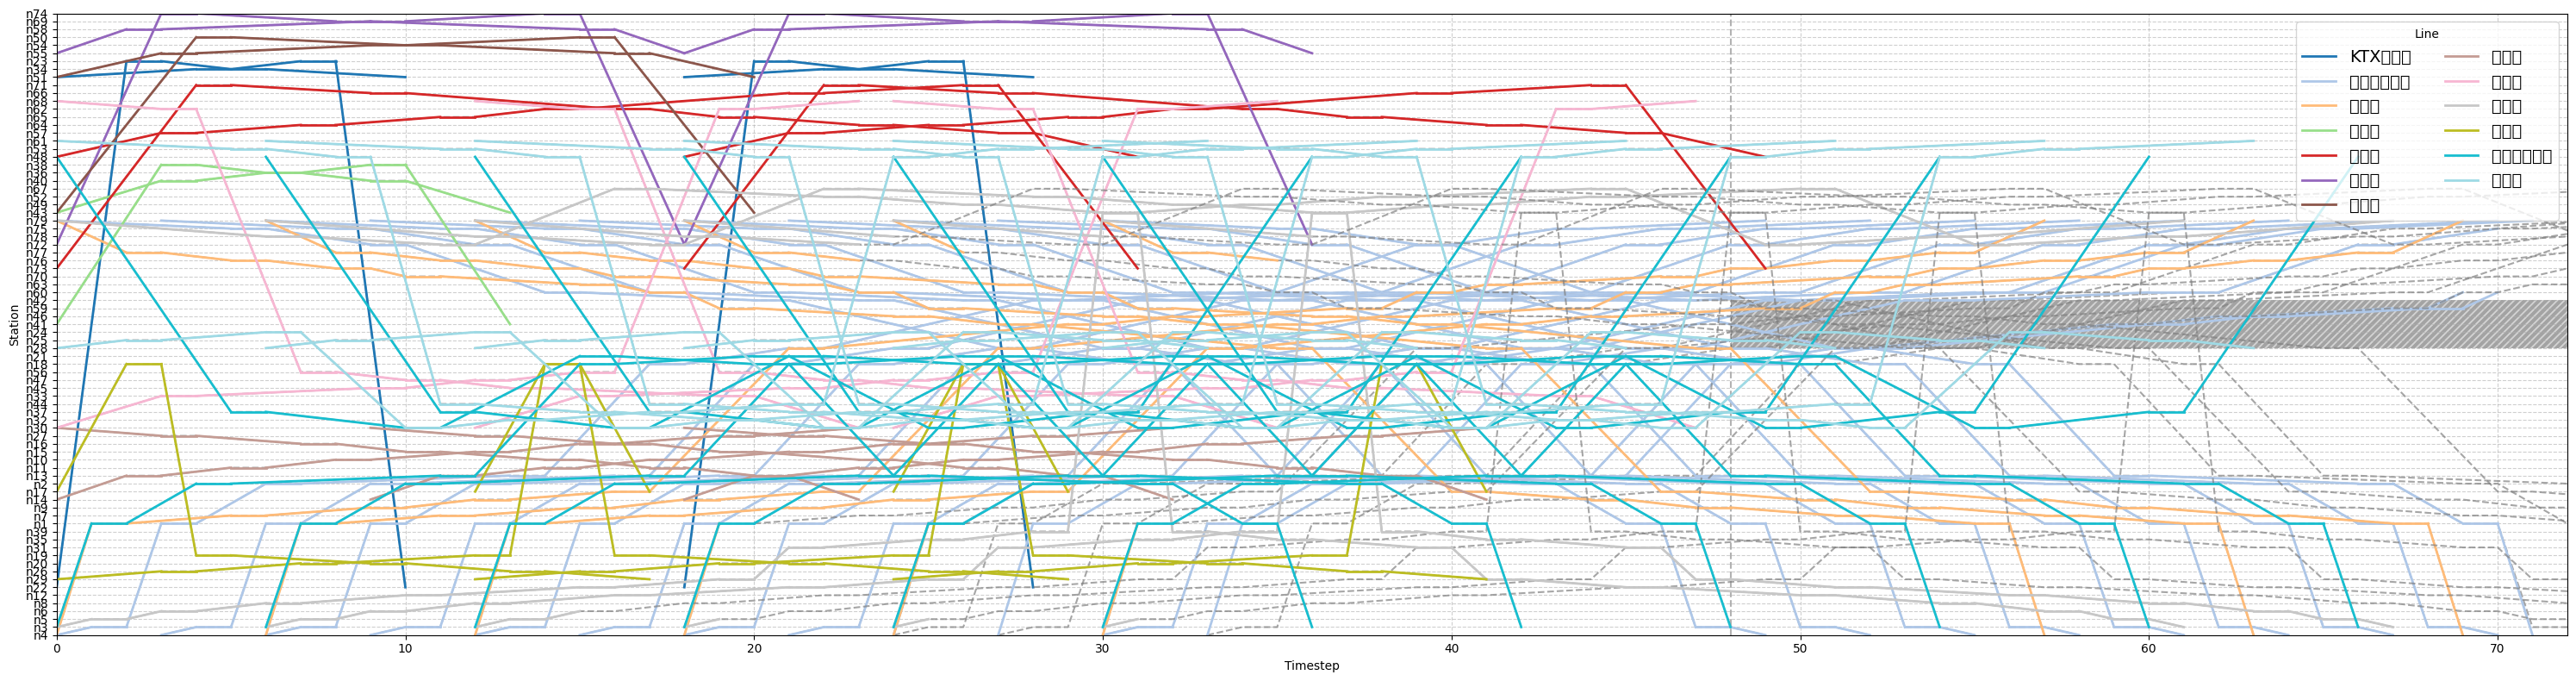

c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:744: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:744: UserWarning: Glyph 47497 (\N{HANGUL SYLLABLE REUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:744: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:744: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\module.py:744: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.tigh

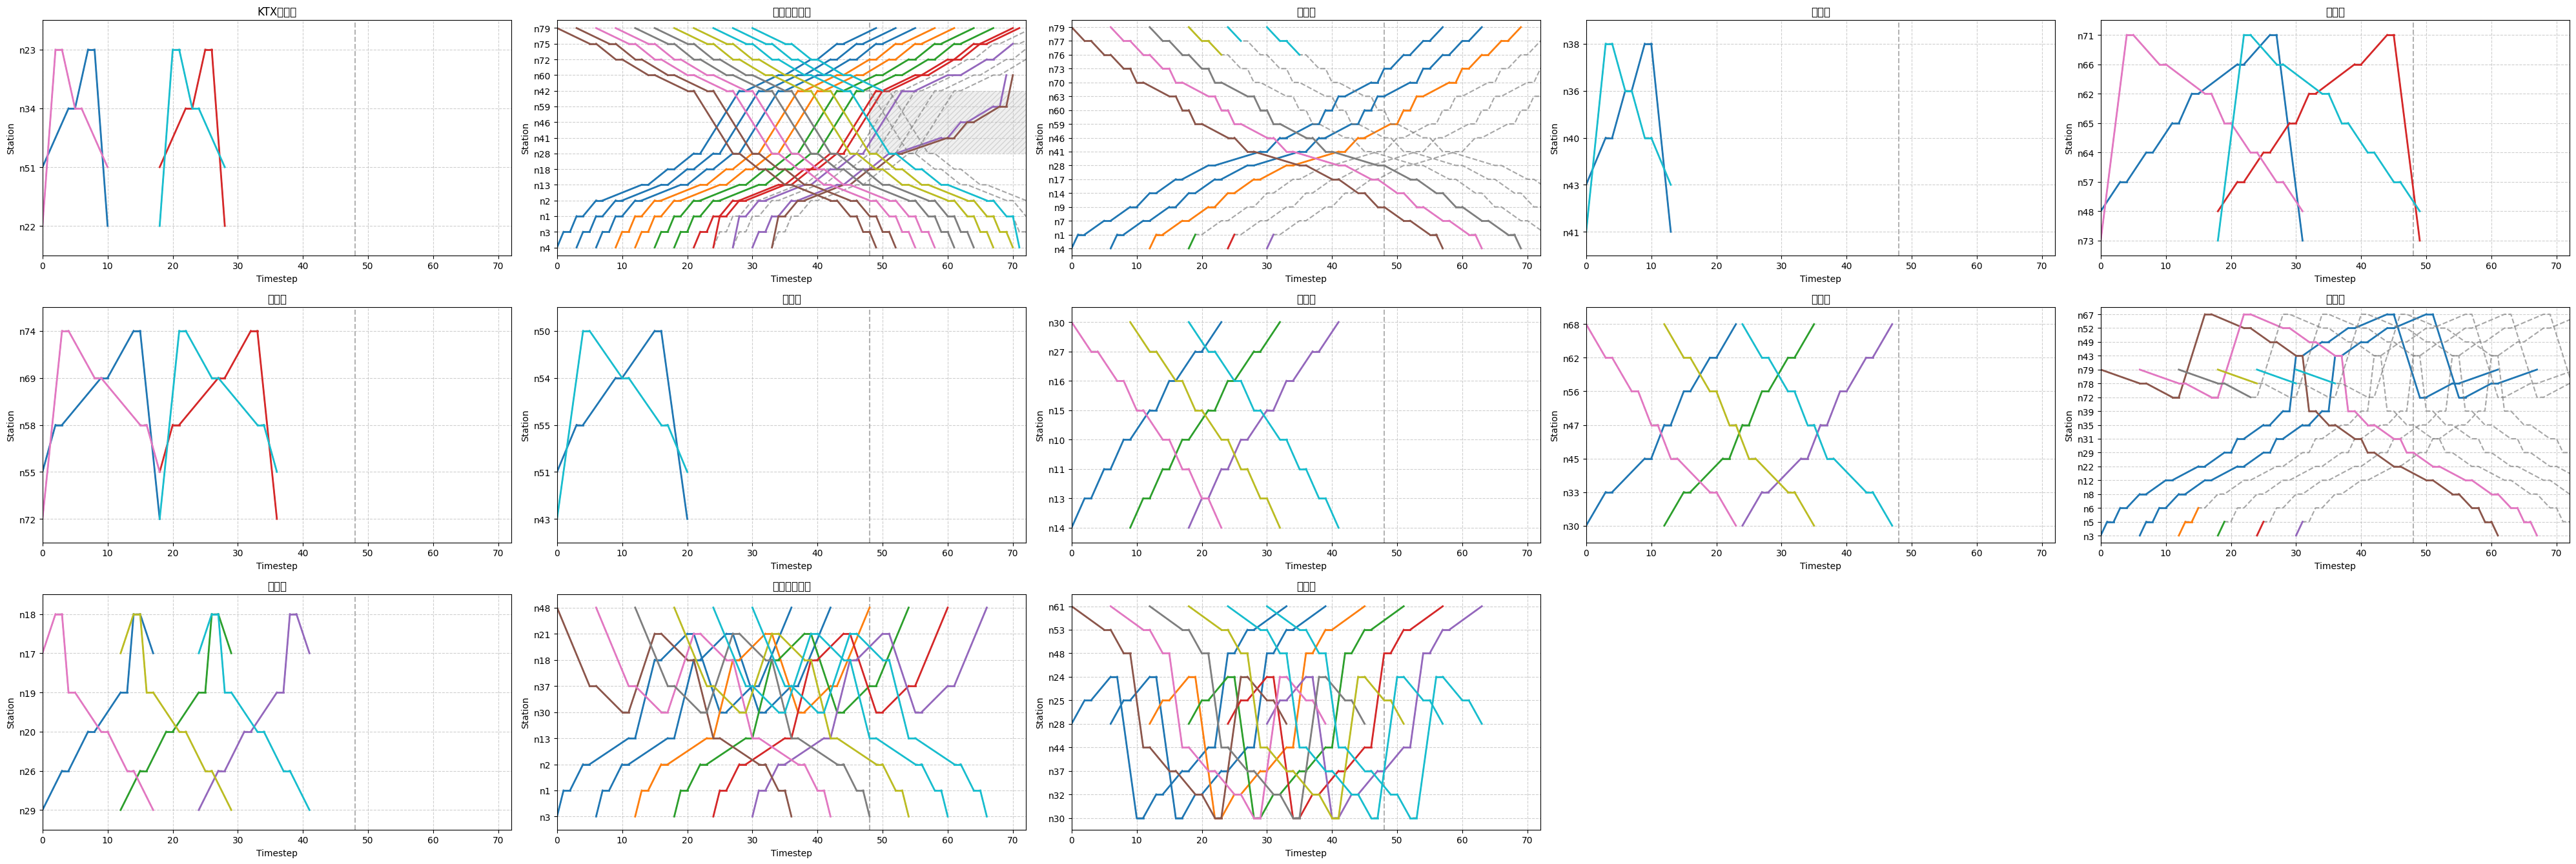

In [18]:
md.h_final = h_final
md.station_map_global = station_map_global
md.by_line = by_line
md.sol_legs = sol_legs
md.visited_by_train = visited_by_train
md.visited_by_line = visited_by_line
md.global_order = global_order

plot_all_lines_global(xmax=72)
plot_lines_dynamic_y(xmax=72)